<a href="https://colab.research.google.com/github/omkulawade03/Dataset/blob/main/task18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import all necessary libraries for the assignment
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import files

uploaded = files.upload()

Saving ford_car_dataset.csv to ford_car_dataset.csv


In [5]:
filepath = "/content/ford_car_dataset.csv"
df = pd.read_csv("ford_car_dataset.csv")

In [11]:

#Q1. Data Loading & Initial Analysis

# Load the dataset
df = pd.read_csv("ford_car_dataset.csv")

# Display the first 10 rows
print("--- FIRST 10 ROWS ---")
print(df.head(10))

# Display the last 5 rows
print("\n--- LAST 5 ROWS ---")
print(df.tail(5))

# Check shape and data types
print("\n--- DATASET SHAPE ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n--- DATA TYPES ---")
print(df.dtypes)

--- FIRST 10 ROWS ---
     model  year  price transmission  mileage fuelType  tax   mpg  engineSize
0   Fiesta  2017  12000    Automatic    15944   Petrol  150  57.7         1.0
1    Focus  2018  14000       Manual     9083   Petrol  150  57.7         1.0
2    Focus  2017  13000       Manual    12456   Petrol  150  57.7         1.0
3   Fiesta  2019  17500       Manual    10460   Petrol  145  40.3         1.5
4   Fiesta  2019  16500    Automatic     1482   Petrol  145  48.7         1.0
5   Fiesta  2015  10500       Manual    35432   Petrol  145  47.9         1.6
6     Puma  2019  22500       Manual     2029   Petrol  145  50.4         1.0
7   Fiesta  2017   9000       Manual    13054   Petrol  145  54.3         1.2
8     Kuga  2019  25500    Automatic     6894   Diesel  145  42.2         2.0
9    Focus  2018  10000       Manual    48141   Petrol  145  61.4         1.0

--- LAST 5 ROWS ---
        model  year  price transmission  mileage fuelType  tax   mpg  \
17961   B-MAX  2017   8999 

In [12]:
#Q2. Missing & Duplicate Values

# Check for missing values
print("--- MISSING VALUES PER COLUMN ---")
print(df.isnull().sum())

# Check for duplicates
duplicate_count = df.duplicated().sum()
print(f"\nTotal duplicate rows found: {duplicate_count}")

# Remove duplicate rows
df_cleaned = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after removing duplicates: {df_cleaned.shape}")

--- MISSING VALUES PER COLUMN ---
model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

Total duplicate rows found: 154
Shape after removing duplicates: (17812, 9)


In [13]:
#Q3. Statistical Summary

# Generate statistical summary for numeric columns
print("--- STATISTICAL SUMMARY OF NUMERIC FEATURES ---")
summary = df_cleaned.describe()
print(summary)

# Highlighting specific metrics for key columns
for col in ['price', 'mileage', 'year']:
    print(f"\nMetrics for '{col}':")
    print(f"  Minimum: {df_cleaned[col].min()}")
    print(f"  Maximum: {df_cleaned[col].max()}")
    print(f"  Mean:    {df_cleaned[col].mean():.2f}")
    print(f"  Median:  {df_cleaned[col].median()}")

--- STATISTICAL SUMMARY OF NUMERIC FEATURES ---
               year         price        mileage           tax           mpg  \
count  17812.000000  17812.000000   17812.000000  17812.000000  17812.000000   
mean    2016.862396  12269.556310   23381.146362    113.315012     57.908696   
std        2.052039   4736.285417   19419.011045     62.034603     10.132696   
min     1996.000000    495.000000       1.000000      0.000000     20.800000   
25%     2016.000000   8999.000000   10000.000000     30.000000     52.300000   
50%     2017.000000  11288.000000   18277.000000    145.000000     58.900000   
75%     2018.000000  15295.000000   31098.500000    145.000000     65.700000   
max     2060.000000  54995.000000  177644.000000    580.000000    201.800000   

         engineSize  
count  17812.000000  
mean       1.350623  
std        0.432581  
min        0.000000  
25%        1.000000  
50%        1.200000  
75%        1.500000  
max        5.000000  

Metrics for 'price':
  Minimum: 

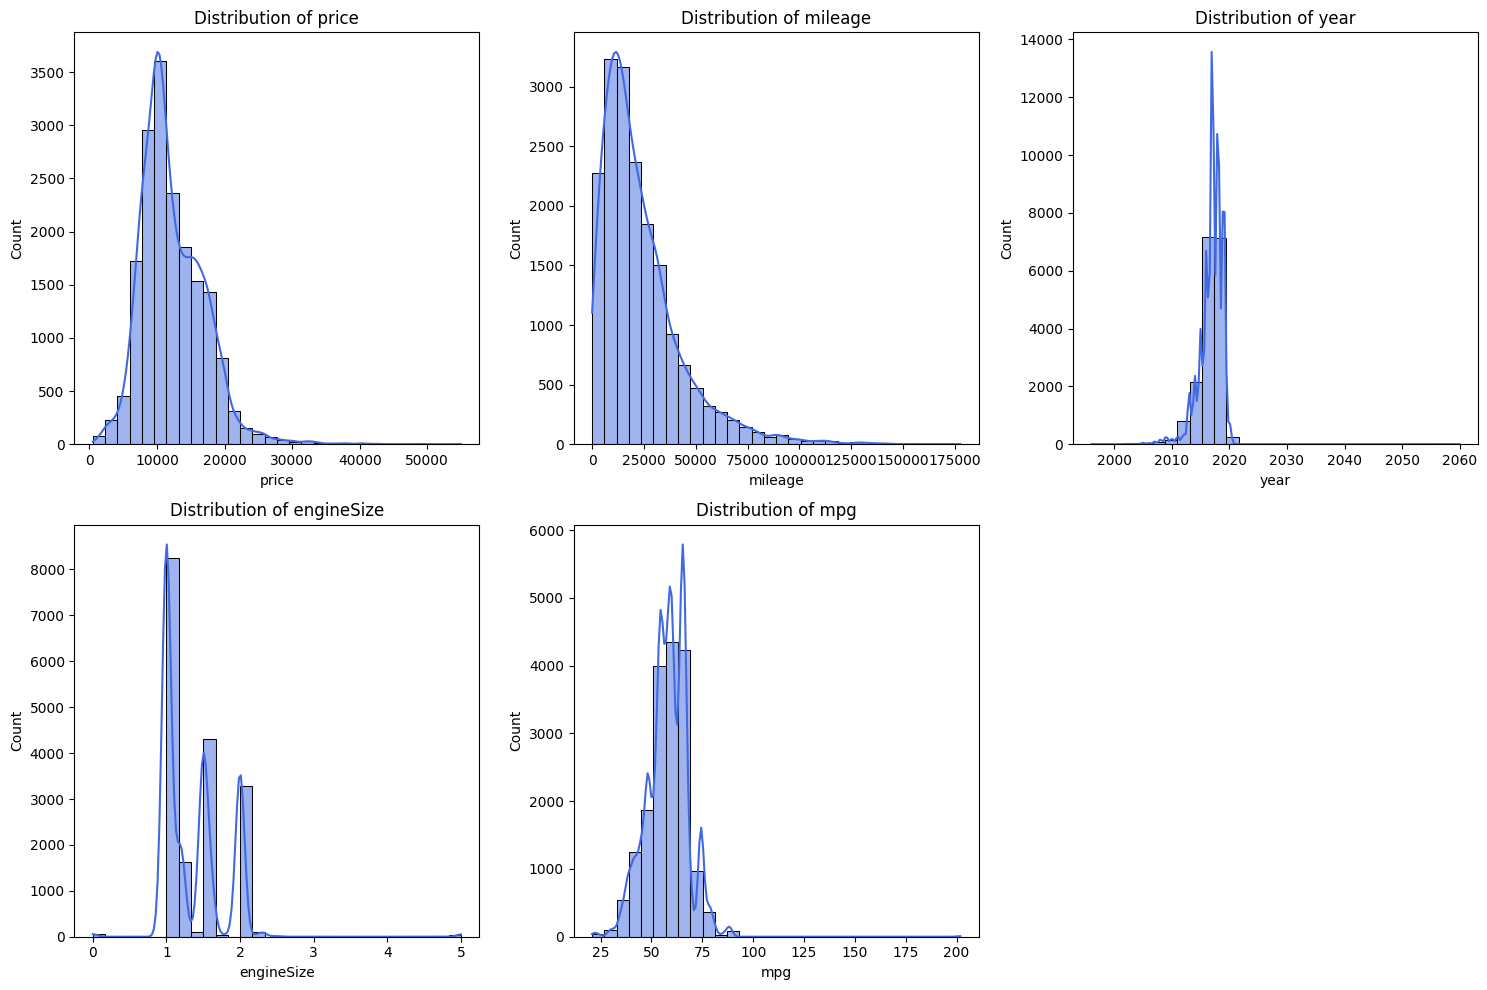

In [14]:
#Q4. Histogram of Numeric Features

numeric_cols = ['price', 'mileage', 'year', 'engineSize', 'mpg']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df_cleaned[col], kde=True, bins=30, color='royalblue')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()



/tmp/ipykernel_773/124186125.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cleaned, x='fuelType', order=df_cleaned['fuelType'].value_counts().index, palette='viridis')
/tmp/ipykernel_773/124186125.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cleaned, x='transmission', order=df_cleaned['transmission'].value_counts().index, palette='viridis')
/tmp/ipykernel_773/124186125.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cleaned[df_cleaned['model'].isin(top_10_models)], y='model', order=top_10_mod

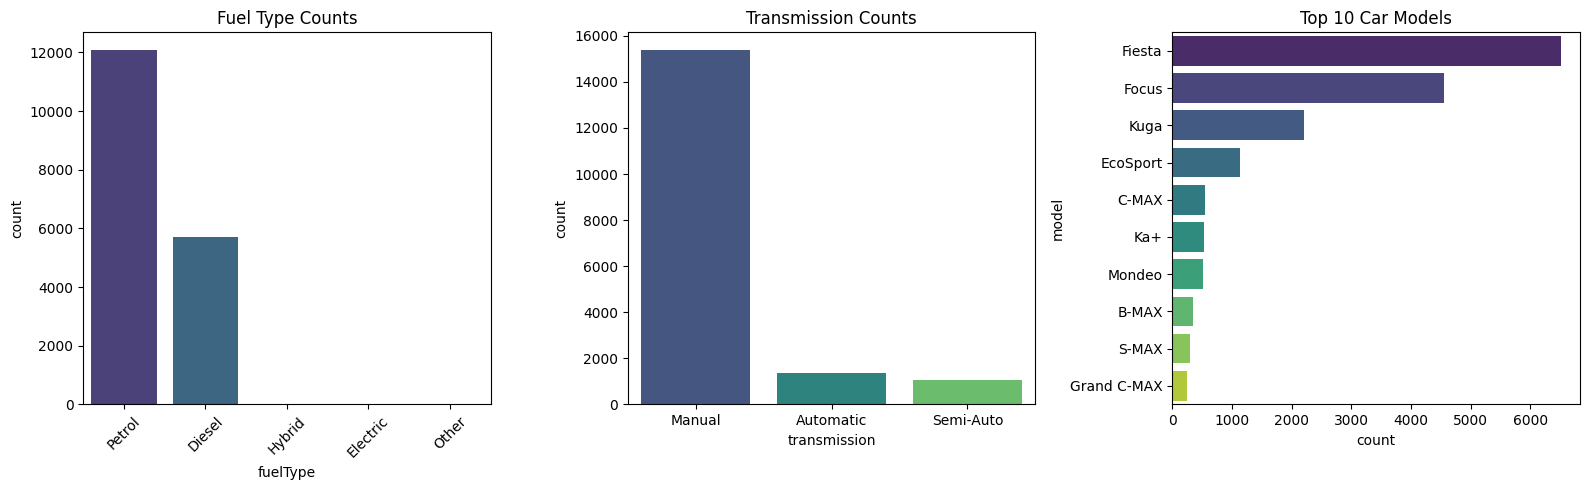

In [15]:
#Q5. Count Plots of Categorical Features

categorical_cols = ['fuelType', 'transmission', 'model']

# Clean string whitespaces just in case
for col in categorical_cols:
    df_cleaned[col] = df_cleaned[col].astype(str).str.strip()

plt.figure(figsize=(16, 5))

# Fuel Type Plot
plt.subplot(1, 3, 1)
sns.countplot(data=df_cleaned, x='fuelType', order=df_cleaned['fuelType'].value_counts().index, palette='viridis')
plt.title('Fuel Type Counts')
plt.xticks(rotation=45)

# Transmission Plot
plt.subplot(1, 3, 2)
sns.countplot(data=df_cleaned, x='transmission', order=df_cleaned['transmission'].value_counts().index, palette='viridis')
plt.title('Transmission Counts')

# Model Plot (Top 10 models for better visual clarity)
plt.subplot(1, 3, 3)
top_10_models = df_cleaned['model'].value_counts().head(10).index
sns.countplot(data=df_cleaned[df_cleaned['model'].isin(top_10_models)], y='model', order=top_10_models, palette='viridis')
plt.title('Top 10 Car Models')

plt.tight_layout()
plt.show()



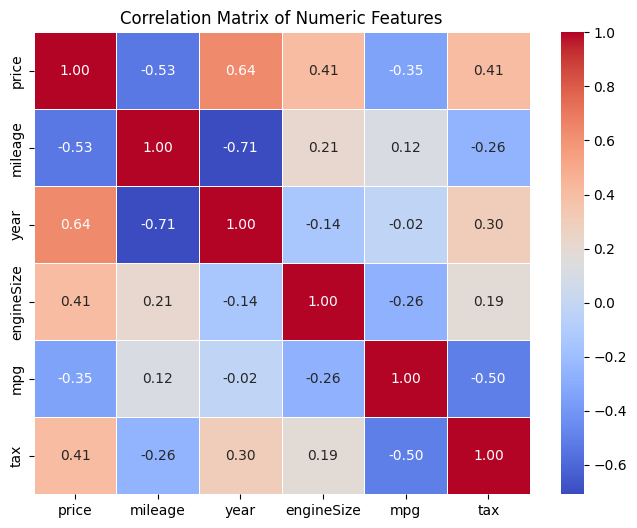

In [16]:
#Q6. Correlation Heatmap

# Compute correlation matrix for numeric columns
corr_matrix = df_cleaned[numeric_cols + ['tax']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features')
plt.show()

In [27]:
# --- Q7 FEATURE IDENTIFICATION ---
# Dependent (Target) Feature
target = 'price'

# Independent (Input) Features
features = df.drop(columns=['price']).columns

print("Dependent (Target) Feature:")
print(target)

print("\nIndependent (Input) Features:")
print(list(features))

Dependent (Target) Feature:
price

Independent (Input) Features:
['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize']


In [23]:
#Q8. Encoding Categorical Variables

from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Show before transformation
print("--- BEFORE TRANSFORMATION ---")
print(df_cleaned[['fuelType', 'transmission']].head(3))

# Initialize OneHotEncoder (drop='first' avoids dummy variable trap)
encoder = OneHotEncoder(sparse_output=False, drop='first')

# Fit and transform target columns
encoded_feats = encoder.fit_transform(df_cleaned[['fuelType', 'transmission']])
encoded_df = pd.DataFrame(encoded_feats, columns=encoder.get_feature_names_out(['fuelType', 'transmission']))

# Combine for comparison
transformed_sample = pd.concat([df_cleaned[['fuelType', 'transmission']].head(3), encoded_df.head(3)], axis=1)

print("\n--- AFTER ONE-HOT ENCODING ---")
print(transformed_sample)

--- BEFORE TRANSFORMATION ---
  fuelType transmission
0   Petrol    Automatic
1   Petrol       Manual
2   Petrol       Manual

--- AFTER ONE-HOT ENCODING ---
  fuelType transmission  fuelType_Electric  fuelType_Hybrid  fuelType_Other  \
0   Petrol    Automatic                0.0              0.0             0.0   
1   Petrol       Manual                0.0              0.0             0.0   
2   Petrol       Manual                0.0              0.0             0.0   

   fuelType_Petrol  transmission_Manual  transmission_Semi-Auto  
0              1.0                  0.0                     0.0  
1              1.0                  1.0                     0.0  
2              1.0                  1.0                     0.0  


In [25]:
#Q9. Feature Scaling

from sklearn.preprocessing import StandardScaler
import pandas as pd

# Select numeric input features (excluding target 'price')
numeric_inputs = ['year', 'mileage', 'tax', 'mpg', 'engineSize']

# Initialize and apply StandardScaler
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_cleaned[numeric_inputs])

# Convert to DataFrame
df_scaled = pd.DataFrame(scaled_features, columns=numeric_inputs)

print("--- FIRST 5 ROWS OF SCALED INPUT FEATURES ---")
print(df_scaled.head(5))

--- FIRST 5 ROWS OF SCALED INPUT FEATURES ---
       year   mileage       tax       mpg  engineSize
0  0.067059 -0.382994  0.591380 -0.020597   -0.810561
1  0.554393 -0.736317  0.591380 -0.020597   -0.810561
2  0.067059 -0.562616  0.591380 -0.020597   -0.810561
3  1.041726 -0.665405  0.510777 -1.737858    0.345325
4  1.041726 -1.127749  0.510777 -0.908836   -0.810561


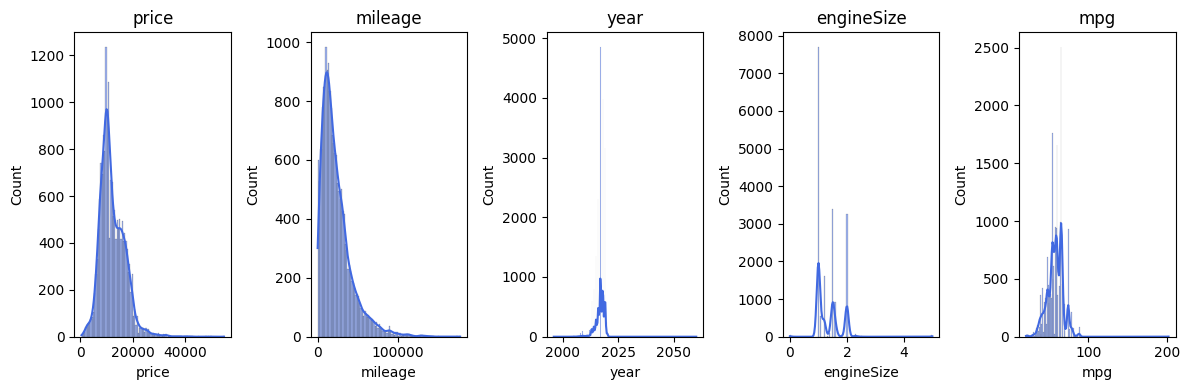

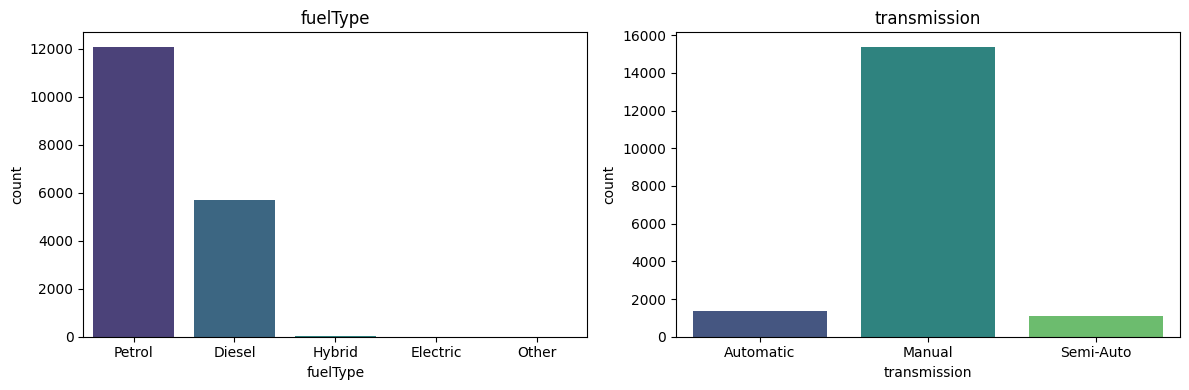

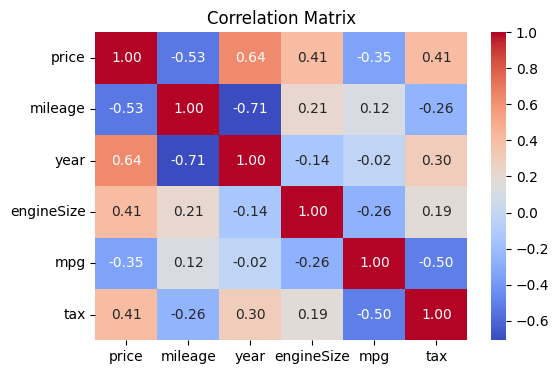

--- PIPELINE EXECUTION COMPLETE ---
Features shape: (17812, 33) | Target shape: (17812,)


In [28]:

from sklearn.preprocessing import OneHotEncoder, StandardScaler

def preprocess_ford_dataset(file_path):
    # 1. Load and clean the data
    df = pd.read_csv(file_path)

    # Trim whitespaces in categorical columns
    for col in ['model', 'transmission', 'fuelType']:
        df[col] = df[col].astype(str).str.strip()

    # Handle duplicates and missing values
    df = df.drop_duplicates().reset_index(drop=True)

    # 2. Perform EDA (Histograms, Count Plots, Heatmap)
    # Histograms
    numeric_cols = ['price', 'mileage', 'year', 'engineSize', 'mpg']
    plt.figure(figsize=(12, 4))
    for i, col in enumerate(numeric_cols, 1):
        plt.subplot(1, 5, i)
        sns.histplot(df[col], kde=True, color='royalblue')
        plt.title(col)
    plt.tight_layout()
    plt.show()

    # Count plots
    plt.figure(figsize=(12, 4))
    for i, col in enumerate(['fuelType', 'transmission'], 1):
        plt.subplot(1, 2, i)
        sns.countplot(data=df, x=col, hue=col, palette='viridis', legend=False)
        plt.title(col)
    plt.tight_layout()
    plt.show()

    # Heatmap
    plt.figure(figsize=(6, 4))
    sns.heatmap(df[numeric_cols + ['tax']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation Matrix')
    plt.show()

    # 3. Identify input and output features
    X_categorical = df[['model', 'transmission', 'fuelType']]
    X_numeric = df[['year', 'mileage', 'tax', 'mpg', 'engineSize']]
    y = df['price']

    # 4. Encode categorical variables
    encoder = OneHotEncoder(sparse_output=False, drop='first')
    X_cat_encoded = pd.DataFrame(
        encoder.fit_transform(X_categorical),
        columns=encoder.get_feature_names_out(['model', 'transmission', 'fuelType'])
    )

    # 5. Scale the numeric features
    scaler = StandardScaler()
    X_num_scaled = pd.DataFrame(scaler.fit_transform(X_numeric), columns=X_numeric.columns)

    # Combine processed features
    X_final = pd.concat([X_num_scaled, X_cat_encoded], axis=1)

    return X_final, y

# Execute the complete pipeline
X, y = preprocess_ford_dataset("ford_car_dataset.csv")
print("--- PIPELINE EXECUTION COMPLETE ---")
print(f"Features shape: {X.shape} | Target shape: {y.shape}")